# Sampling

### Basic random variable sampling

In [1]:
import numpy as np
from relife.lifetime_models import Weibull

weibull = Weibull(7, 0.05)

In [2]:
weibull.rvs((3, 2), seed=3)

array([[22.74126812, 21.07048501],
       [16.12599226, 18.31960308],
       [22.61436487, 19.49711465]])

You can apply condition, either with initial ages or ages of replacement. `a0` and `ar` values must be broadcastable with the `rvs` size.

In [3]:
weibull.apply_condition(a0=np.array([[5], [10]])).rvs((2, 4), seed=3)

array([[17.74133337, 16.07060372, 11.12661386, 13.31989001],
       [12.62501588,  9.52300994,  9.17180879, 11.8237418 ]])

In [4]:
weibull.apply_condition(ar=np.array([10, 20])).rvs((4, 2), seed=3)

array([[10.        , 20.        ],
       [10.        , 18.31960308],
       [10.        , 19.49711465],
       [10.        , 20.        ]])

### Generate lifetimes from a renewal process

In [5]:
from relife.sampling import sample_lifetimes_from_renewal_process

lifetime_sample = sample_lifetimes_from_renewal_process(
    weibull, 40, time_window=(20, 100), ar=22, seed=3
)
print(len(lifetime_sample.time))

217


The result is a named tuple of `time`, `event` and `entry`

In [6]:
print(weibull.get_params())
print(Weibull().fit(*lifetime_sample).get_params())

[7.   0.05]
[7.61306357 0.0492674 ]


To generate observations with different `covar`, we can loop on `sample_lifetimes_from_renewal_process` for different values of `covar`

In [7]:
from relife.lifetime_models import ParametricProportionalHazard

regression = ParametricProportionalHazard(weibull, coefficients=(2, 1.5))
print(regression.get_params())

[2.   1.5  7.   0.05]


In [8]:
regression.mean(0.21, 0.18)

array(16.95257886)

In [9]:
z1 = (0.3, 0.21)  # 2 values of z1
z2 = (0.12, 0.18)  # 2 values of z2
lifetime_sample_0 = sample_lifetimes_from_renewal_process(
    regression, 40, time_window=(20, 100), covar=(z1[0], z2[0])
)
lifetime_sample_1 = sample_lifetimes_from_renewal_process(
    regression, 40, time_window=(20, 100), covar=(z1[1], z2[1])
)

time = np.concat([lifetime_sample_0.time, lifetime_sample_1.time])
event = np.concat([lifetime_sample_0.event, lifetime_sample_1.event])
entry = np.concat([lifetime_sample_0.entry, lifetime_sample_1.entry])
z1 = np.array(
    [
        z1[0],
    ]
    * len(lifetime_sample_0.time)
    + [
        z1[1],
    ]
    * len(lifetime_sample_1.time)
)
z2 = np.array(
    [
        z2[0],
    ]
    * len(lifetime_sample_0.time)
    + [
        z2[1],
    ]
    * len(lifetime_sample_1.time)
)

In [10]:
print(
    ParametricProportionalHazard(Weibull())
    .fit(time, covar=(z1, z2), event=event, entry=entry)
    .get_params()
)

[-0.28265442 -0.16647146  6.78505924  0.05403068]


### Sample renewal process

In [11]:
from relife.sampling import sample_process
from relife.stochastic_processes import RenewalProcess

renewal_process = RenewalProcess(weibull)

sample = sample_process(renewal_process, 100, (0, 75), seed=10)
print(sample.events.shape)
print(sample.timeline.shape)

(100, 349)
(349,)


The sample size is 100, meaning 100 realizations of the stochastic process in (0, 75) time window.

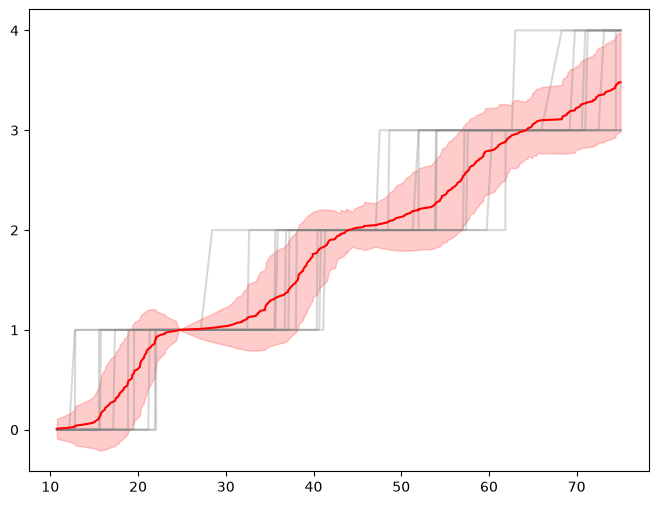

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
cumul_events = sample.events.cumsum(axis=1)

for sample_id in range(10):
    ax.plot(sample.timeline, cumul_events[sample_id], alpha=0.3, color="gray")

mean = cumul_events.mean(axis=0)
std = cumul_events.std(axis=0)
ax.plot(sample.timeline, mean, color="red")
ax.fill_between(sample.timeline, mean - std, mean + std, color="red", alpha=0.2)

### Sample non-homogeneous Poisson process

In [13]:
from relife.stochastic_processes import NonHomogeneousPoissonProcess

nhpp = NonHomogeneousPoissonProcess(weibull)
sample = sample_process(nhpp, 100, (0, 100), ar=30, seed=10)

The sample size is 100, meaning 100 realizations of the stochastic process in (0, 100) time window. An age of replacement at 30 years is passed too.

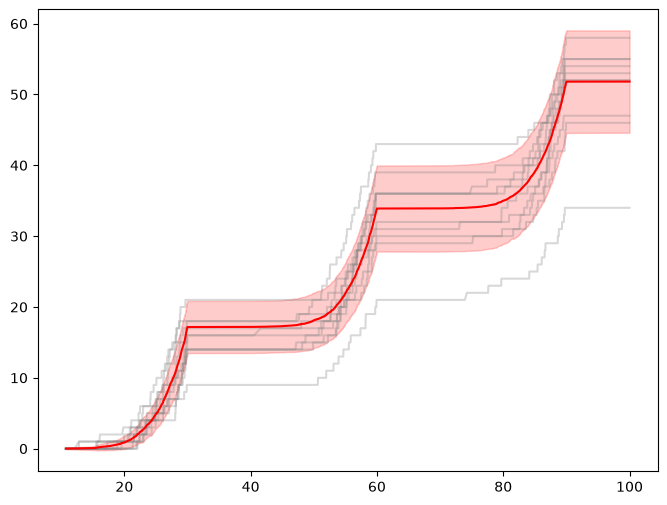

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
cumul_events = sample.events.cumsum(axis=1)

for sample_id in range(10):
    ax.plot(sample.timeline, cumul_events[sample_id], alpha=0.3, color="gray")

mean = cumul_events.mean(axis=0)
std = cumul_events.std(axis=0)
ax.plot(sample.timeline, mean, color="red")
ax.fill_between(sample.timeline, mean - std, mean + std, color="red", alpha=0.2)

### Sample Kijima 1 process

In [15]:
from relife.stochastic_processes import Kijima1Process

kijima_1 = Kijima1Process(weibull, q=0.7)
sample = sample_process(kijima_1, 100, (0, 100), ar=25, seed=10)

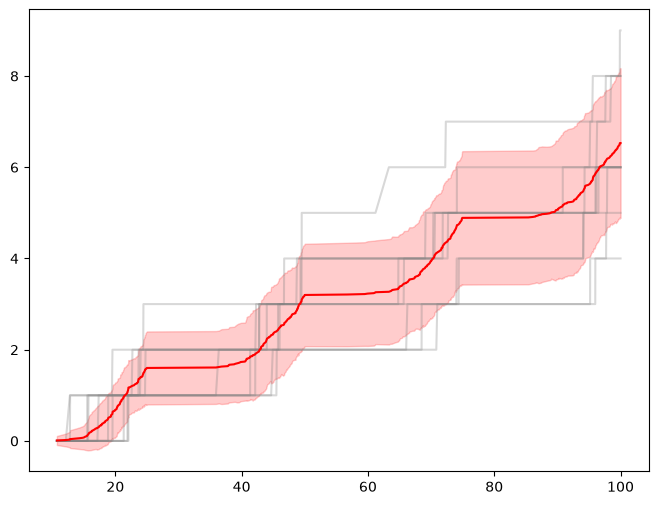

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
cumul_events = sample.events.cumsum(axis=1)

for sample_id in range(10):
    ax.plot(sample.timeline, cumul_events[sample_id], alpha=0.3, color="gray")

mean = cumul_events.mean(axis=0)
std = cumul_events.std(axis=0)
ax.plot(sample.timeline, mean, color="red")
ax.fill_between(sample.timeline, mean - std, mean + std, color="red", alpha=0.2)

### Sample Kijima 2 process

In [17]:
from relife.stochastic_processes import Kijima2Process

kijima_2 = Kijima2Process(weibull, q=0.7)
sample = sample_process(kijima_2.freeze(), 100, (0, 100), ar=25, seed=10)

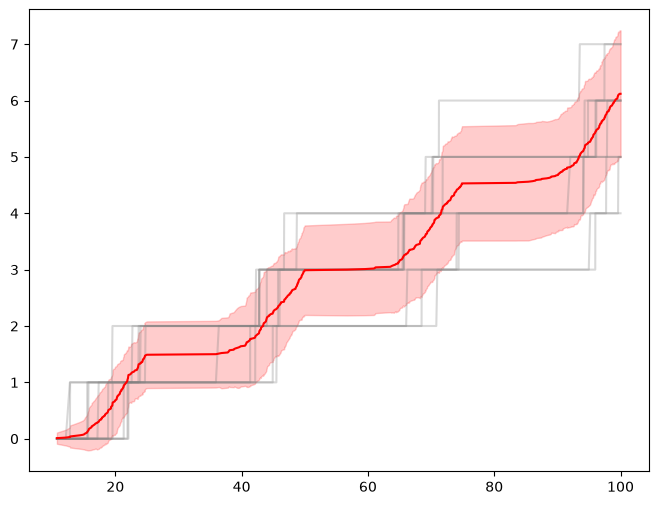

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
cumul_events = sample.events.cumsum(axis=1)

for sample_id in range(10):
    ax.plot(sample.timeline, cumul_events[sample_id], alpha=0.3, color="gray")

mean = cumul_events.mean(axis=0)
std = cumul_events.std(axis=0)
ax.plot(sample.timeline, mean, color="red")
ax.fill_between(sample.timeline, mean - std, mean + std, color="red", alpha=0.2)